In [3]:
# Nguyễn Hoàng Tùng

# === 6.2 (b) Dataset Generation ===
import os
import numpy as np
import pandas as pd
from faker import Faker

fake = Faker()
np.random.seed(42)

# Preferred and fallback directories
preferred_dir = r"D:\lecture\PTIT\20251\IntSys"
fallback_dir  = r"D:\PTIT\20251\IntSys"
out_dir = preferred_dir if os.path.exists(preferred_dir) else fallback_dir

os.makedirs(out_dir, exist_ok=True)
print(f"Data will be stored in: {out_dir}")

# ---- Basic specs ----
n_users = 1000
n_items = 500

# ---- 1. Users table ----
users = pd.DataFrame({
    "userId": np.arange(1, n_users + 1),
    "age": np.random.randint(18, 70, n_users),
    "gender": np.random.choice(["M", "F", "O"], n_users, p=[0.48, 0.48, 0.04]),
    "signup_days_ago": np.random.randint(1, 2000, n_users)
})
users_path = os.path.join(out_dir, "users.csv")
users.to_csv(users_path, index=False)

# ---- 2. Items table ----
categories = ["phone", "laptop", "clothes", "home", "books", "toys", "accessories"]
items = pd.DataFrame({
    "itemId": np.arange(1, n_items + 1),
    "category": np.random.choice(categories, n_items),
    "price": np.round(np.random.lognormal(mean=4.0, sigma=0.8, size=n_items), 2),
    "title": [fake.sentence(nb_words=3).rstrip('.') for _ in range(n_items)]
})
items_path = os.path.join(out_dir, "items.csv")
items.to_csv(items_path, index=False)

# ---- 3. Ratings table ----
rows = []
for u in users["userId"]:
    k = np.random.randint(20, 61)  # each user rates 20–60 items
    item_ids = np.random.choice(items["itemId"], size=k, replace=False)
    for it in item_ids:
        rating = np.random.choice([1,2,3,4,5], p=[0.05,0.1,0.2,0.4,0.25])
        ts = pd.Timestamp.now() - pd.Timedelta(days=int(np.random.exponential(scale=200)))
        rows.append((u, int(it), int(rating), ts))
ratings = pd.DataFrame(rows, columns=["userId", "itemId", "rating", "timestamp"])
ratings_path = os.path.join(out_dir, "ratings.csv")
ratings.to_csv(ratings_path, index=False)

# ---- 4. Vietnamese-style review generation ----
vn_words = [
    "tốt", "xấu", "giá", "đẹp", "không", "rất", "hài lòng", "thất vọng",
    "chất lượng", "giao hàng", "nhanh", "chậm", "đóng gói", "tận tình",
    "đổi trả", "ưu đãi", "đáng tiền"
]

rev_rows = []
for u in users["userId"]:
    k = np.random.randint(20, 61)
    item_ids = np.random.choice(items["itemId"], size=k, replace=False)
    for it in item_ids:
        review = " ".join(np.random.choice(vn_words, size=np.random.randint(5, 15)))
        rev_rows.append((u, int(it), review))
reviews = pd.DataFrame(rev_rows, columns=["userId", "itemId", "review_text"])

# Save main required CSV
review_path = os.path.join(out_dir, "itemReview_tungnh.csv")
reviews.to_csv(review_path, index=False)

# ---- Summary preview ----
print("\nFiles created:")
for f in [users_path, items_path, ratings_path, review_path]:
    print(" •", f)
print("\nSample preview:")
display(users.head(3))
display(items.head(3))
display(ratings.head(3))
display(reviews.sample(5))


Data will be stored in: D:\lecture\PTIT\20251\IntSys

Files created:
 • D:\lecture\PTIT\20251\IntSys\users.csv
 • D:\lecture\PTIT\20251\IntSys\items.csv
 • D:\lecture\PTIT\20251\IntSys\ratings.csv
 • D:\lecture\PTIT\20251\IntSys\itemReview_tungnh.csv

Sample preview:


,userId,age,gender,signup_days_ago
0,1,56,F,348
1,2,69,M,627
2,3,46,M,1128


,itemId,category,price,title
0,1,clothes,55.23,Reflect democratic in
1,2,home,61.86,Move small service
2,3,home,64.17,Wife establish white when


,userId,itemId,rating,timestamp
0,1,495,4,2025-09-25 22:07:47.230214
1,1,444,2,2022-01-16 22:07:47.231919
2,1,34,3,2025-01-06 22:07:47.231958


,userId,itemId,review_text
30826,767,266,giá đóng gói chất lượng đóng gói tốt giao hàng...
21305,530,275,giao hàng rất ưu đãi tận tình rất nhanh
11165,276,314,xấu ưu đãi hài lòng giá chất lượng không
14440,360,239,hài lòng giao hàng chất lượng nhanh xấu giá
29201,728,357,chậm đáng tiền không đổi trả đổi trả chậm khôn...


In [5]:
# Nguyễn Hoàng Tùng

import os
import pandas as pd

# Auto-detect dataset path
preferred_dir = r"D:\lecture\PTIT\20251\IntSys"
fallback_dir  = r"D:\PTIT\20251\IntSys"
data_dir = preferred_dir if os.path.exists(preferred_dir) else fallback_dir

review_path = os.path.join(data_dir, "itemReview_tungnh.csv")
reviews = pd.read_csv(review_path)
print("Loaded reviews:", reviews.shape)
reviews.head(5)

import re
from underthesea import word_tokenize

# Basic Vietnamese stopword list
stopwords = {
    "và","là","có","cho","với","của","một","những","rất","đã","thì",
    "khi","được","này","ở","trên","dưới","từ","bị","đến","tới","rằng",
    "lúc","nào","ra","nhiều","ít","hơn","nữa","vẫn","vì","để","cũng",
    "nên","như","tại","do","sẽ","các","vào","đó"
}

def clean_vn(text):
    text = re.sub(r"[^a-zA-ZÀ-ỹ\s]", " ", str(text))
    text = re.sub(r"\s+", " ", text).strip().lower()
    tokens = word_tokenize(text, format="text").split()
    tokens = [t for t in tokens if t not in stopwords]
    return " ".join(tokens)

reviews["clean_text"] = reviews["review_text"].apply(clean_vn)
print("Cleaned text sample:")
print(reviews["clean_text"].head(10))

from sklearn.feature_extraction.text import TfidfVectorizer

# TF-IDF representation
vectorizer = TfidfVectorizer(max_features=5000)
X_tfidf = vectorizer.fit_transform(reviews["clean_text"])

print("TF-IDF matrix shape:", X_tfidf.shape)
print("Sample features:", vectorizer.get_feature_names_out()[:15])

# Example: view first review’s top 10 weighted terms
tfidf_weights = zip(vectorizer.get_feature_names_out(), X_tfidf[0].toarray().flatten())
top_terms = sorted(tfidf_weights, key=lambda x: -x[1])[:10]
print("\nTop 10 weighted terms in first review:")
for term, weight in top_terms:
    if weight > 0:
        print(f"{term}: {weight:.4f}")

# Install first-time only: pip install sentence-transformers
from sentence_transformers import SentenceTransformer
import numpy as np

bert_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Encode a small sample to show structure (to save time)
sample_texts = reviews["clean_text"].sample(5, random_state=42).tolist()
bert_embeddings = bert_model.encode(sample_texts, convert_to_numpy=True)

print("BERT embeddings shape:", bert_embeddings.shape)
for text, vec in zip(sample_texts, bert_embeddings):
    print("\nReview:", text)
    print("First 10 dims:", np.round(vec[:10], 3))


Loaded reviews: (40019, 3)
Cleaned text sample:
0    đáng tiền tận_tình giao hàng đổi trả hài_lòng ...
1    đẹp không tốt đổi trả không xấu chậm đẹp giao ...
2    đáng tiền đóng_gói không đáng tiền không tận_tình
3    tận_tình giá chậm không đáng tiền xấu không đẹ...
4              thất_vọng hài_lòng ưu_đãi tận_tình chậm
5                      nhanh chất_lượng tốt ưu_đãi xấu
6    chậm giá chậm hài_lòng không tốt đổi trả đáng ...
7    đóng_gói không chậm giao hàng tốt thất_vọng kh...
8    chất_lượng giao hàng xấu không không đẹp nhanh...
9    thất_vọng chất_lượng không đáng tiền đóng_gói ...
Name: clean_text, dtype: object
TF-IDF matrix shape: (40019, 43)
Sample features: ['chất_lượng' 'chậm' 'chậm_giá' 'chậm_đổi' 'giao' 'giá' 'hài_lòng' 'hàng'
 'hàng_không' 'không' 'nhanh' 'nhanh_giá' 'nhanh_đáng' 'nhanh_đẹp'
 'nhanh_đổi']

Top 10 weighted terms in first review:
hài_lòng: 0.5718
tốt: 0.3932
xấu: 0.3839
trả: 0.2007
hàng: 0.1956
đổi: 0.1947
đáng: 0.1911
chất_lượng: 0.1911
tận_tình: 0.191

modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

C:\Users\Admin\AppData\Roaming\Python\Python313\site-packages\huggingface_hub\file_download.py:143: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Admin\.cache\huggingface\hub\models--sentence-transformers--paraphrase-multilingual-MiniLM-L12-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

Xet Storage is enabled for this repo, but the 'hf_xet' package is not installed. Falling back to regular HTTP download. For better performance, install the package with: `pip install huggingface_hub[hf_xet]` or `pip install hf_xet`


tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

BERT embeddings shape: (5, 384)

Review: tốt thất_vọng giá giá hài_lòng chất_lượng chậm tốt tốt thất_vọng xấu tận_tình xấu
First 10 dims: [ 0.042 -0.003 -0.006  0.061 -0.073 -0.045  0.288  0.12   0.068  0.011]

Review: hài_lòng hài_lòng đáng tiền ưu_đãi nhanh giao hàng đẹp xấu đổi trả
First 10 dims: [ 0.047  0.02  -0.032  0.131  0.023 -0.128  0.389 -0.098 -0.005 -0.09 ]

Review: không thất_vọng nhanh tận_tình đóng_gói giá
First 10 dims: [ 0.025  0.148  0.034  0.008 -0.064 -0.105  0.147  0.054  0.004  0.038]

Review: giá tốt tận_tình đẹp chậm đẹp
First 10 dims: [-0.068  0.044  0.022 -0.026 -0.12  -0.11  -0.084  0.171  0.107 -0.031]

Review: xấu không ưu_đãi chất_lượng tốt hài_lòng xấu hài_lòng giao hàng xấu đẹp ưu_đãi
First 10 dims: [ 0.068 -0.021 -0.046  0.071 -0.049 -0.047  0.395  0.105 -0.043 -0.058]


Ratings shape: (39784, 4)


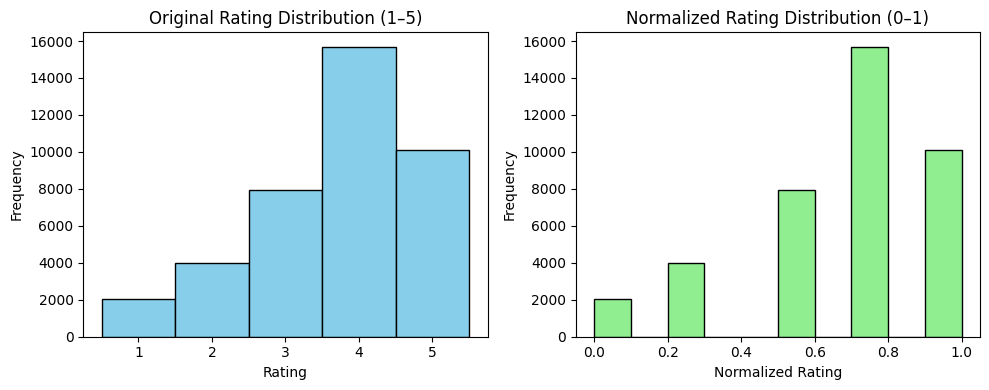

User–Item matrix shape: (1000, 500)


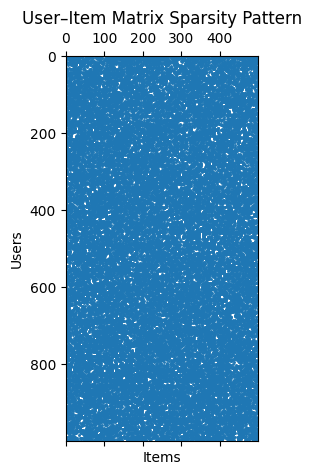

Matrix sparsity: 92.45%


In [6]:
# Nguyễn Hoàng Tùng

import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

# Auto-detect dataset directory
preferred_dir = r"D:\lecture\PTIT\20251\IntSys"
fallback_dir  = r"D:\PTIT\20251\IntSys"
data_dir = preferred_dir if os.path.exists(preferred_dir) else fallback_dir

# Load ratings
ratings_path = os.path.join(data_dir, "ratings.csv")
ratings = pd.read_csv(ratings_path)
print("Ratings shape:", ratings.shape)
ratings.head(5)

# Normalize rating values to [0, 1]
ratings["rating_norm"] = (ratings["rating"] - ratings["rating"].min()) / (ratings["rating"].max() - ratings["rating"].min())
ratings[["rating", "rating_norm"]].head(10)

# Plot distribution before and after normalization
fig, axs = plt.subplots(1, 2, figsize=(10,4))

axs[0].hist(ratings["rating"], bins=np.arange(0.5,6.5,1), color="skyblue", edgecolor="black")
axs[0].set_title("Original Rating Distribution (1–5)")
axs[0].set_xlabel("Rating")
axs[0].set_ylabel("Frequency")

axs[1].hist(ratings["rating_norm"], bins=10, color="lightgreen", edgecolor="black")
axs[1].set_title("Normalized Rating Distribution (0–1)")
axs[1].set_xlabel("Normalized Rating")
axs[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

# Create a user–item matrix (sparse structure)
user_item_matrix = ratings.pivot_table(index="userId", columns="itemId", values="rating_norm").fillna(0)
print("User–Item matrix shape:", user_item_matrix.shape)
user_item_matrix.head(10)

# Visualize sparsity pattern (optional for large data)
plt.figure(figsize=(6,5))
plt.spy(user_item_matrix, markersize=1)
plt.title("User–Item Matrix Sparsity Pattern")
plt.xlabel("Items")
plt.ylabel("Users")
plt.show()

sparsity = 1.0 - (np.count_nonzero(user_item_matrix.values) / user_item_matrix.size)
print(f"Matrix sparsity: {sparsity:.2%}")


Train: (31827, 7)  Test: (7957, 7)


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 input_2 (InputLayer)        [(None, 1)]                  0         []                            
                                                                                                  
 embedding (Embedding)       (None, 1, 50)                50000     ['input_1[0][0]']             
                                                                                                  
 embedding_1 (Embedding)     (None, 1, 50)                25000     ['input_2[0][0]']             
                                                         

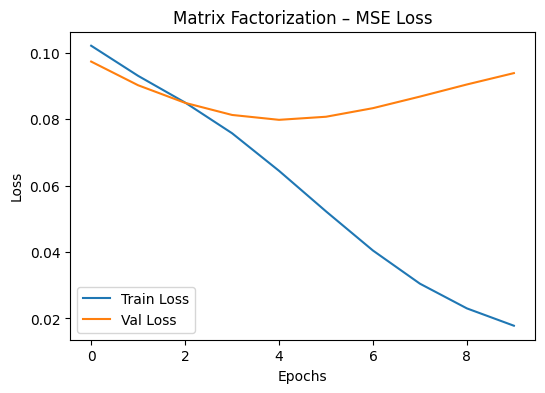

249/249 [==============================] - 0s 687us/step
Matrix Factorization Test MSE: 0.0939


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ input_layer_1 (InputLayer)    │ (None, 1)                 │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding (Embedding)         │ (None, 1, 64)             │          64,000 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_1 (Embedding)       │ (None, 1, 64)             │          32,000 │ input_layer_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten (Flatten)             │ (None, 64)                │               0 │ embedding[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ flatten_1 (Flatten)           │ (None, 64)                │               0 │ embedding_1[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate (Concatenate)     │ (None, 128)               │               0 │ flatten[0][0],             │
│                               │                           │                 │ flatten_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense (Dense)                 │ (None, 128)               │          16,512 │ concatenate[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout (Dropout)             │ (None, 128)               │               0 │ dense[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_1 (Dense)               │ (None, 64)                │           8,256 │ dropout[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_2 (Dense)               │ (None, 32)                │           2,080 │ dense_1[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_3 (Dense)               │ (None, 1)                 │              33 │ dense_2[0][0]              │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 122,881 (480.00 KB)

 Trainable params: 122,881 (480.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0791 - mae: 0.2287 - val_loss: 0.0765 - val_mae: 0.2289
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0753 - mae: 0.2210 - val_loss: 0.0770 - val_mae: 0.2258
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0738 - mae: 0.2182 - val_loss: 0.0778 - val_mae: 0.2220
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0716 - mae: 0.2142 - val_loss: 0.0792 - val_mae: 0.2257
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0673 - mae: 0.2066 - val_loss: 0.0829 - val_mae: 0.2269
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0605 - mae: 0.1956 - val_loss: 0.0876 - val_mae: 0.2353
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0536 - mae: 0.1839 - val_loss: 0.0894 - val_mae: 0.2358
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0474 - mae: 0.1725 - val_loss: 0.0938 - val_mae: 0.2422
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - lo

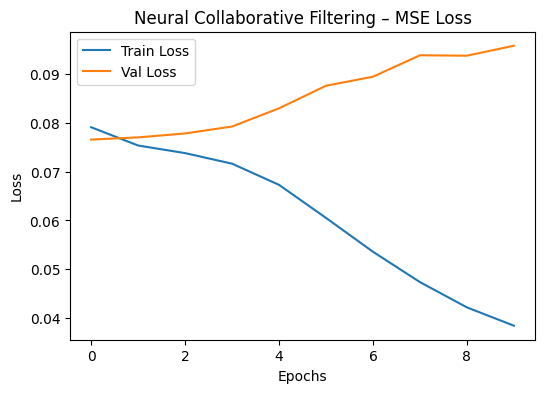

249/249 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
NCF Test MSE: 0.0958
Improvement over MF baseline: -1.99%


In [7]:
# Nguyễn Hoàng Tùng

import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Load normalized ratings
import os
preferred_dir = r"D:\lecture\PTIT\20251\IntSys"
fallback_dir  = r"D:\PTIT\20251\IntSys"
data_dir = preferred_dir if os.path.exists(preferred_dir) else fallback_dir

ratings = pd.read_csv(os.path.join(data_dir, "ratings.csv"))
ratings["rating_norm"] = (ratings["rating"] - ratings["rating"].min()) / (ratings["rating"].max() - ratings["rating"].min())

# Encode user and item IDs as categorical integers
user_ids = ratings["userId"].unique()
item_ids = ratings["itemId"].unique()
user2idx = {u: i for i, u in enumerate(user_ids)}
item2idx = {m: i for i, m in enumerate(item_ids)}

ratings["user_idx"] = ratings["userId"].map(user2idx)
ratings["item_idx"] = ratings["itemId"].map(item2idx)

train, test = train_test_split(ratings, test_size=0.2, random_state=42)
print("Train:", train.shape, " Test:", test.shape)

# === Matrix Factorization Model ===
n_users = len(user2idx)
n_items = len(item2idx)
latent_dim = 50

user_input = tf.keras.layers.Input(shape=(1,))
item_input = tf.keras.layers.Input(shape=(1,))

user_vec = tf.keras.layers.Embedding(n_users, latent_dim, input_length=1)(user_input)
item_vec = tf.keras.layers.Embedding(n_items, latent_dim, input_length=1)(item_input)

dot = tf.keras.layers.Dot(axes=2)([user_vec, item_vec])
dot = tf.keras.layers.Flatten()(dot)
output = tf.keras.layers.Dense(1, activation='sigmoid')(dot)

mf_model = tf.keras.models.Model([user_input, item_input], output)
mf_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
mf_model.summary()

history_mf = mf_model.fit(
    [train.user_idx, train.item_idx],
    train.rating_norm,
    validation_data=([test.user_idx, test.item_idx], test.rating_norm),
    epochs=10,
    batch_size=256,
    verbose=1
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.plot(history_mf.history['loss'], label='Train Loss')
plt.plot(history_mf.history['val_loss'], label='Val Loss')
plt.title("Matrix Factorization – MSE Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_pred = mf_model.predict([test.user_idx, test.item_idx])
mse = np.mean((test_pred.flatten() - test.rating_norm.values)**2)
print(f"Matrix Factorization Test MSE: {mse:.4f}")

# === Neural Collaborative Filtering (NCF) Model ===
from tensorflow.keras import layers, Model

latent_dim = 64

user_input = layers.Input(shape=(1,))
item_input = layers.Input(shape=(1,))

user_embed = layers.Embedding(n_users, latent_dim)(user_input)
item_embed = layers.Embedding(n_items, latent_dim)(item_input)

# Flatten and concatenate
u = layers.Flatten()(user_embed)
i = layers.Flatten()(item_embed)
x = layers.Concatenate()([u, i])

# Deep layers for non-linear interactions
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
output = layers.Dense(1, activation='sigmoid')(x)

ncf_model = Model([user_input, item_input], output)
ncf_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
ncf_model.summary()

history_ncf = ncf_model.fit(
    [train.user_idx, train.item_idx],
    train.rating_norm,
    validation_data=([test.user_idx, test.item_idx], test.rating_norm),
    epochs=10,
    batch_size=256,
    verbose=1
)

plt.figure(figsize=(6,4))
plt.plot(history_ncf.history['loss'], label='Train Loss')
plt.plot(history_ncf.history['val_loss'], label='Val Loss')
plt.title("Neural Collaborative Filtering – MSE Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

test_pred_ncf = ncf_model.predict([test.user_idx, test.item_idx])
mse_ncf = np.mean((test_pred_ncf.flatten() - test.rating_norm.values)**2)
print(f"NCF Test MSE: {mse_ncf:.4f}")

improvement = (mse - mse_ncf) / mse * 100
print(f"Improvement over MF baseline: {improvement:.2f}%")


Classification rows: (2544, 6)
Full df (regression) rows: (40019, 6)
sentiment
1.0    0.806604
0.0    0.193396
Name: proportion, dtype: float64
Vocabulary size (tokenizer): 27
Sample sequence: [12 11 16 23 26 27  4  5  0  0  0  0  0  0  0  0  0  0  0  0]
Class Train/Val: (2035, 100) (509, 100)
Reg Train/Val: (32015, 100) (8004, 100)


C:\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)    │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_2 (Embedding)       │ (None, 100, 128)          │       1,280,000 │ input_layer_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d (Conv1D)               │ (None, 98, 128)           │          49,280 │ embedding_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_1 (Conv1D)             │ (None, 97, 128)           │          65,664 │ embedding_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ conv1d_2 (Conv1D)             │ (None, 96, 128)           │          82,048 │ embedding_2[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d          │ (None, 128)               │               0 │ conv1d[0][0]               │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_1        │ (None, 128)               │               0 │ conv1d_1[0][0]             │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ global_max_pooling1d_2        │ (None, 128)               │               0 │ conv1d_2[0][0]             │
│ (GlobalMaxPooling1D)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_1 (Concatenate)   │ (None, 384)               │               0 │ global_max_pooling1d[0][0… │
│                               │                           │                 │ global_max_pooling1d_1[0]… │
│                               │                           │                 │ global_max_pooling1d_2[0]… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_1 (Dropout)           │ (None, 384)               │               0 │ concatenate_1[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_4 (Dense)               │ (None, 64)                │          24,640 │ dropout_1[0][0]            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_2 (Dropout)           │ (None, 64)                │               0 │ dense_4[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_5 (Dense)               │ (None, 1)                 │              65 │ dropout_2[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,501,697 (5.73 MB)

 Trainable params: 1,501,697 (5.73 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 334ms/step - accuracy: 0.8025 - loss: 0.5445 - val_accuracy: 0.8075 - val_loss: 0.5137
Epoch 2/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 5s 288ms/step - accuracy: 0.8064 - loss: 0.5105 - val_accuracy: 0.8075 - val_loss: 0.4944
Epoch 3/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 268ms/step - accuracy: 0.8064 - loss: 0.4953 - val_accuracy: 0.8075 - val_loss: 0.4945
Epoch 4/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 280ms/step - accuracy: 0.8064 - loss: 0.4940 - val_accuracy: 0.8075 - val_loss: 0.4934
Epoch 5/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - accuracy: 0.8064 - loss: 0.4903 - val_accuracy: 0.8075 - val_loss: 0.4938
Epoch 6/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 284ms/step - accuracy: 0.8064 - loss: 0.4879 - val_accuracy: 0.8075 - val_loss: 0.4947
Epoch 7/12
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 298ms/step - accuracy: 0.8064 - loss: 0.4834 - val_accuracy: 0.8075 - val_loss: 0.4950


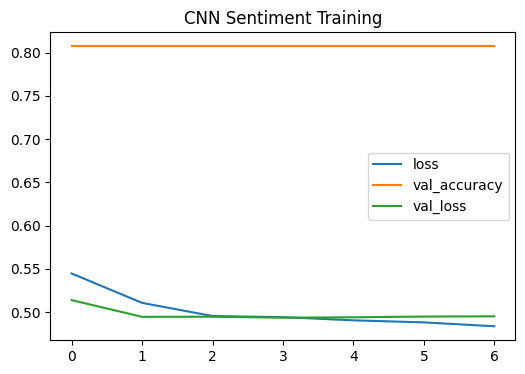

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
ROC AUC: 0.48592283628779975

Classification report (CNN):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        98
           1     0.8075    1.0000    0.8935       411

    accuracy                         0.8075       509
   macro avg     0.4037    0.5000    0.4467       509
weighted avg     0.6520    0.8075    0.7215       509

Confusion matrix:
 [[  0  98]
 [  0 411]]


C:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Python313\Lib\site-packages\keras\src\layers\core\embedding.p

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_3 (Embedding)              │ (None, 100, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ simple_rnn (SimpleRNN)               │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,321,217 (5.04 MB)

 Trainable params: 1,321,217 (5.04 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
126/126 ━━━━━━━━━━━━━━━━━━━━ 19s 135ms/step - loss: 0.0354 - mae: 0.1091 - val_loss: 0.0073 - val_mae: 0.0345
Epoch 2/8
126/126 ━━━━━━━━━━━━━━━━━━━━ 19s 124ms/step - loss: 0.0096 - mae: 0.0606 - val_loss: 0.0107 - val_mae: 0.0768
Epoch 3/8
126/126 ━━━━━━━━━━━━━━━━━━━━ 21s 131ms/step - loss: 0.0085 - mae: 0.0531 - val_loss: 0.0087 - val_mae: 0.0592
Epoch 4/8
126/126 ━━━━━━━━━━━━━━━━━━━━ 20s 125ms/step - loss: 0.0080 - mae: 0.0487 - val_loss: 0.0089 - val_mae: 0.0611


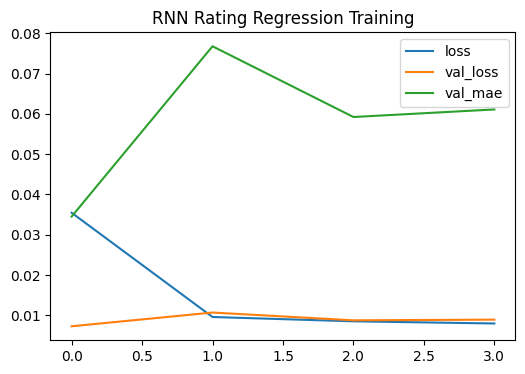

251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
RNN RMSE: 0.0844, MAE: 0.0345


C:\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_4 (Embedding)              │ (None, 100, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 256)                 │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,559,681 (5.95 MB)

 Trainable params: 1,559,681 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 336ms/step - accuracy: 0.7838 - loss: 0.5367 - val_accuracy: 0.8075 - val_loss: 0.4968
Epoch 2/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 10s 287ms/step - accuracy: 0.8064 - loss: 0.4964 - val_accuracy: 0.8075 - val_loss: 0.4920
Epoch 3/8
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 277ms/step - accuracy: 0.8064 - loss: 0.4954 - val_accuracy: 0.8075 - val_loss: 0.4949


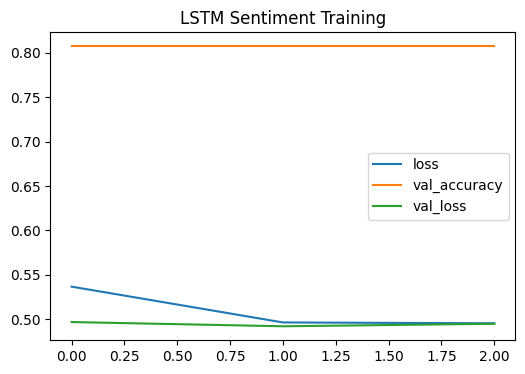

16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 45ms/step
LSTM ROC AUC: 0.44534237052485226

Classification report (LSTM):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        98
           1     0.8075    1.0000    0.8935       411

    accuracy                         0.8075       509
   macro avg     0.4037    0.5000    0.4467       509
weighted avg     0.6520    0.8075    0.7215       509



C:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


Batches:   0%|          | 0/1001 [00:00<?, ?it/s]

Batches:   0%|          | 0/251 [00:00<?, ?it/s]

C:\Python313\Lib\site-packages\keras\src\layers\core\embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ seq_in (InputLayer)           │ (None, 100)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ embedding_5 (Embedding)       │ (None, 100, 128)          │       1,280,000 │ seq_in[0][0]               │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ lstm_1 (LSTM)                 │ (None, 64)                │          49,408 │ embedding_5[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bert_in (InputLayer)          │ (None, 384)               │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ concatenate_2 (Concatenate)   │ (None, 448)               │               0 │ lstm_1[0][0],              │
│                               │                           │                 │ bert_in[0][0]              │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_10 (Dense)              │ (None, 64)                │          28,736 │ concatenate_2[0][0]        │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dropout_6 (Dropout)           │ (None, 64)                │               0 │ dense_10[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ dense_11 (Dense)              │ (None, 1)                 │              65 │ dropout_6[0][0]            │
└───────────────────────────────┴───────────────────────────┴─────────────────┴────────────────────────────┘

 Total params: 1,358,209 (5.18 MB)

 Trainable params: 1,358,209 (5.18 MB)

 Non-trainable params: 0 (0.00 B)

IndexError: index 34256 is out of bounds for axis 0 with size 32015

In [9]:
# Nguyễn Hoàng Tùng

# 6.2(f) Cell 1 — Prepare labels and dataset for text tasks
import os
import numpy as np
import pandas as pd

# locate data dir as before
preferred_dir = r"D:\lecture\PTIT\20251\IntSys"
fallback_dir  = r"D:\PTIT\20251\IntSys"
data_dir = preferred_dir if os.path.exists(preferred_dir) else fallback_dir

reviews = pd.read_csv(os.path.join(data_dir, "itemReview_tungnh.csv"))
# Load ratings and add normalized column if missing
ratings = pd.read_csv(os.path.join(data_dir, "ratings.csv"))

if "rating_norm" not in ratings.columns:
    ratings["rating_norm"] = (
        (ratings["rating"] - ratings["rating"].min()) /
        (ratings["rating"].max() - ratings["rating"].min())
    )

# Safe merge (now rating_norm always exists)
df = reviews.merge(ratings[["userId","itemId","rating","rating_norm"]], on=["userId","itemId"], how="left")

# create targets:
# Binary sentiment label: positive (1) if rating >=4, negative (0) if rating <=2. Exclude neutral(3) for binary task.
df['sentiment'] = df['rating'].apply(lambda r: 1 if r>=4 else (0 if r<=2 else np.nan))
# Regression target: normalized rating (rating_norm) — already present
# Filter rows for classification (drop neutral)
df_class = df.dropna(subset=['sentiment']).reset_index(drop=True)
print("Classification rows:", df_class.shape)
print("Full df (regression) rows:", df.shape)

# quick class balance
print(df_class['sentiment'].value_counts(normalize=True))

# 6.2(f) Cell 2 — Tokenize & pad sequences (Keras tokenizer)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Use the cleaned text if available; else fallback to review_text
if 'clean_text' in df.columns:
    texts_all = df['clean_text'].astype(str).tolist()
    texts_cls = df_class['clean_text'].astype(str).tolist()
else:
    texts_all = df['review_text'].astype(str).tolist()
    texts_cls = df_class['review_text'].astype(str).tolist()

vocab_size = 10000   # adjust for memory
maxlen = 100         # max tokens per review (truncate/pad to this length)
tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(texts_all)

# sequences
X_seq = tokenizer.texts_to_sequences(texts_all)
X_seq = pad_sequences(X_seq, maxlen=maxlen, padding='post', truncating='post')

X_seq_cls = tokenizer.texts_to_sequences(texts_cls)
X_seq_cls = pad_sequences(X_seq_cls, maxlen=maxlen, padding='post', truncating='post')

# tokens -> check
print("Vocabulary size (tokenizer):", min(vocab_size, len(tokenizer.word_index)))
print("Sample sequence:", X_seq_cls[0][:20])

# 6.2(f) Cell 3 — Create train/test splits
from sklearn.model_selection import train_test_split

# For classification
y_cls = df_class['sentiment'].astype(int).values
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X_seq_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls)

# For regression (use full dataset, fillna rating_norm if missing with mean)
df['rating_norm'] = df['rating_norm'].fillna(df['rating_norm'].mean())
y_reg = df['rating_norm'].values
X_train_r, X_val_r, y_train_r, y_val_r = train_test_split(X_seq, y_reg, test_size=0.2, random_state=42)

print("Class Train/Val:", X_train_c.shape, X_val_c.shape)
print("Reg Train/Val:", X_train_r.shape, X_val_r.shape)

# 6.2(f) Cell 4 — Common callbacks & utilities
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
# small function to plot training history
import matplotlib.pyplot as plt
def plot_history(history, title='Training'):
    plt.figure(figsize=(6,4))
    for k,v in history.history.items():
        if k.startswith('loss') or k.startswith('val_'):
            plt.plot(v, label=k)
    plt.title(title)
    plt.legend()
    plt.show()

# 6.2(f) Cell 5 — Build & train a CNN text classifier (binary sentiment)
from tensorflow.keras import layers, models, regularizers

embed_dim = 128

def build_cnn_classifier(vocab_size, embed_dim=128, maxlen=100, l2_reg=1e-6):
    inp = layers.Input(shape=(maxlen,))
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=maxlen)(inp)
    # 1D conv blocks with multiple kernel sizes
    convs = []
    for k in [3,4,5]:
        c = layers.Conv1D(filters=128, kernel_size=k, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
        c = layers.GlobalMaxPooling1D()(c)
        convs.append(c)
    x = layers.Concatenate()(convs)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn_model = build_cnn_classifier(vocab_size, embed_dim, maxlen)
cnn_model.summary()

history_cnn = cnn_model.fit(
    X_train_c, y_train_c,
    validation_data=(X_val_c, y_val_c),
    epochs=12,
    batch_size=256,
    callbacks=[es],
    verbose=1
)

plot_history(history_cnn, title='CNN Sentiment Training')

# 6.2(f) Cell 6 — Evaluate CNN classifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

y_pred_p = cnn_model.predict(X_val_c).flatten()
y_pred = (y_pred_p >= 0.5).astype(int)

print("ROC AUC:", roc_auc_score(y_val_c, y_pred_p))
print("\nClassification report (CNN):")
print(classification_report(y_val_c, y_pred, digits=4))
cm = confusion_matrix(y_val_c, y_pred)
print("Confusion matrix:\n", cm)

# 6.2(f) Cell 7 — Build & train a simple RNN (vanilla RNN) for regression (rating prediction)
def build_rnn_regressor(vocab_size, embed_dim=128, maxlen=100, l2_reg=1e-6):
    inp = layers.Input(shape=(maxlen,))
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=maxlen)(inp)
    x = layers.SimpleRNN(128, return_sequences=False, kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(64, activation='relu')(x)
    out = layers.Dense(1, activation='linear')(x)  # regression target (0..1)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    return model

rnn_model = build_rnn_regressor(vocab_size, embed_dim, maxlen)
rnn_model.summary()

history_rnn = rnn_model.fit(
    X_train_r, y_train_r,
    validation_data=(X_val_r, y_val_r),
    epochs=8,
    batch_size=256,
    callbacks=[es],
    verbose=1
)

plot_history(history_rnn, title='RNN Rating Regression Training')

# 6.2(f) Cell 8 — Evaluate RNN regressor
from sklearn.metrics import mean_squared_error, mean_absolute_error
y_pred_rnn = rnn_model.predict(X_val_r).flatten()
rmse_rnn = np.sqrt(mean_squared_error(y_val_r, y_pred_rnn))
mae_rnn = mean_absolute_error(y_val_r, y_pred_rnn)
print(f"RNN RMSE: {rmse_rnn:.4f}, MAE: {mae_rnn:.4f}")

# 6.2(f) Cell 9 — Build & train an LSTM classifier (binary) and demonstrate regularization
def build_lstm_classifier(vocab_size, embed_dim=128, maxlen=100, l2_reg=1e-6):
    inp = layers.Input(shape=(maxlen,))
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=maxlen)(inp)
    x = layers.Bidirectional(layers.LSTM(128, return_sequences=False, kernel_regularizer=regularizers.l2(l2_reg)))(x)
    x = layers.Dropout(0.5)(x)
    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

lstm_model = build_lstm_classifier(vocab_size, embed_dim, maxlen)
lstm_model.summary()

history_lstm = lstm_model.fit(
    X_train_c, y_train_c,
    validation_data=(X_val_c, y_val_c),
    epochs=8,
    batch_size=128,
    callbacks=[es],
    verbose=1
)

plot_history(history_lstm, title='LSTM Sentiment Training')

# 6.2(f) Cell 10 — Evaluate LSTM classifier
y_pred_p_lstm = lstm_model.predict(X_val_c).flatten()
y_pred_lstm = (y_pred_p_lstm >= 0.5).astype(int)

print("LSTM ROC AUC:", roc_auc_score(y_val_c, y_pred_p_lstm))
print("\nClassification report (LSTM):")
print(classification_report(y_val_c, y_pred_lstm, digits=4))

# 6.2(f) Cell 11 — Hybrid: concatenate Sentence-BERT embeddings with LSTM output for regression
# We will load a small set of BERT embeddings (from Part c). If you encoded all reviews earlier, you can map them.
# For demo, we compute sentence embeddings for the regression set's validation and training texts (may be slow).
from sentence_transformers import SentenceTransformer

bert_model = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# compute embeddings for regression train/val texts (use cleaned texts)
texts_reg = texts_all  # earlier variable: full list
# to save time, compute only for the split indices
# compute embeddings for X_train_r and X_val_r indices
# Need to map: X_train_r and X_val_r came from texts_all order; we kept order in sequences -> so create indices

# Get original texts array
texts_arr = np.array(texts_all)
# Create train/val index masks using sklearn split earlier — but we don't have indices: recompute split indices deterministically:
from sklearn.model_selection import train_test_split
idxs = np.arange(len(texts_arr))
idx_train, idx_val = train_test_split(idxs, test_size=0.2, random_state=42)

# Compute embeddings (sample or full if you have resources)
train_texts_bert = texts_arr[idx_train].tolist()
val_texts_bert = texts_arr[idx_val].tolist()

# For speed, encode in batches
emb_train = bert_model.encode(train_texts_bert, convert_to_numpy=True, show_progress_bar=True)
emb_val = bert_model.encode(val_texts_bert, convert_to_numpy=True, show_progress_bar=True)

# Build a simple LSTM-based regressor that consumes sequence + BERT vector
from tensorflow.keras import Input, Model
seq_in = Input(shape=(maxlen,), name='seq_in')
bert_in = Input(shape=(emb_train.shape[1],), name='bert_in')

x_seq = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=maxlen)(seq_in)
x_seq = layers.LSTM(64)(x_seq)
x = layers.Concatenate()([x_seq, bert_in])
x = layers.Dense(64, activation='relu')(x)
x = layers.Dropout(0.3)(x)
out = layers.Dense(1, activation='linear')(x)

hybrid_model = Model([seq_in, bert_in], out)
hybrid_model.compile(optimizer='adam', loss='mse', metrics=['mae'])
hybrid_model.summary()

# For training use corresponding y_train_r, y_val_r. But we must align order: idx_train corresponds to X_train_r rows.
# Prepare seq inputs matched to idx_train / idx_val
X_seq_arr = np.array(X_seq)  # full sequence array from earlier
X_seq_train_h = X_seq_arr[idx_train]
X_seq_val_h   = X_seq_arr[idx_val]

# Train (use small epochs)
history_hybrid = hybrid_model.fit(
    [X_seq_train_h, emb_train], y_train_r[idx_train],
    validation_data=([X_seq_val_h, emb_val], y_val_r[idx_val]),
    epochs=6,
    batch_size=128,
    callbacks=[es],
    verbose=1
)

plot_history(history_hybrid, title='Hybrid LSTM+BERT Regression Training')
y_pred_h = hybrid_model.predict([X_seq_val_h, emb_val]).flatten()
rmse_hybrid = np.sqrt(mean_squared_error(y_val_r[idx_val], y_pred_h))
print(f"Hybrid model RMSE: {rmse_hybrid:.4f}")


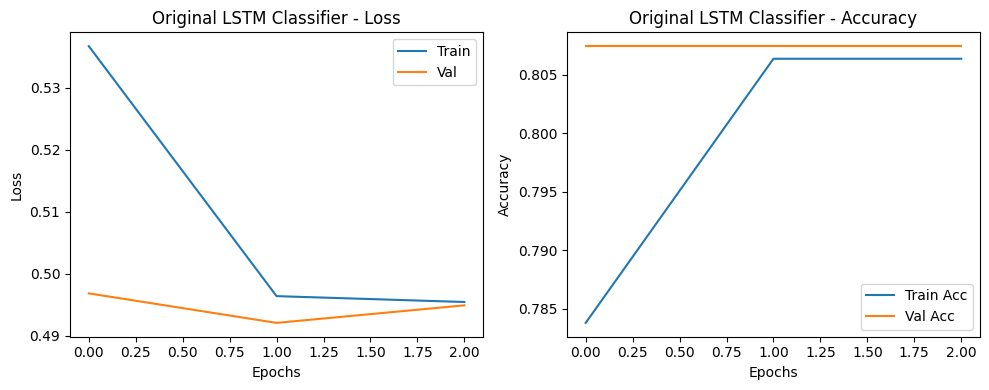

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)           │ (None, 100)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ embedding_6 (Embedding)              │ (None, 100, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 256)                 │         263,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_8 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,559,681 (5.95 MB)

 Trainable params: 1,559,681 (5.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 327ms/step - accuracy: 0.7902 - loss: 0.5569 - val_accuracy: 0.8075 - val_loss: 0.5047
Epoch 2/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 9s 271ms/step - accuracy: 0.8064 - loss: 0.5065 - val_accuracy: 0.8075 - val_loss: 0.5025
Epoch 3/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 297ms/step - accuracy: 0.8064 - loss: 0.5087 - val_accuracy: 0.8075 - val_loss: 0.5148
Epoch 4/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 271ms/step - accuracy: 0.8064 - loss: 0.5074 - val_accuracy: 0.8075 - val_loss: 0.5042
Epoch 5/15
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 286ms/step - accuracy: 0.8064 - loss: 0.5077 - val_accuracy: 0.8075 - val_loss: 0.5061


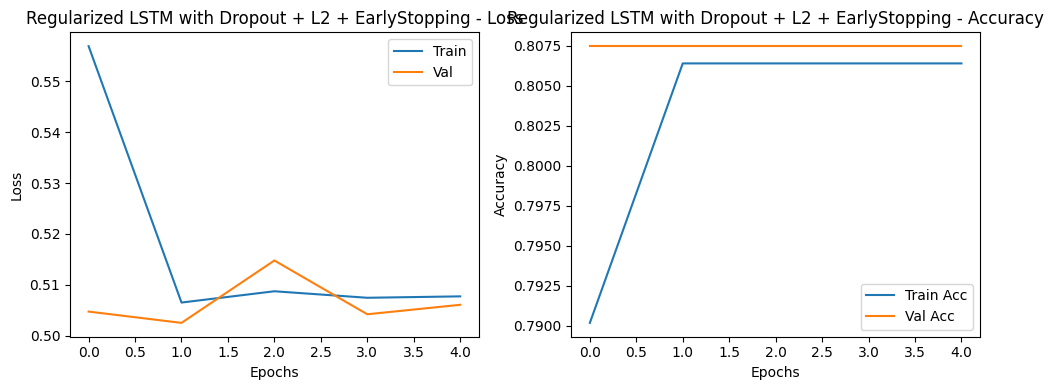

16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 43ms/step
Original LSTM AUC: 0.5000
Regularized LSTM AUC: 0.5000

Improvement in generalization: 0.0 %

Classification report (Regularized LSTM):
              precision    recall  f1-score   support

           0     0.0000    0.0000    0.0000        98
           1     0.8075    1.0000    0.8935       411

    accuracy                         0.8075       509
   macro avg     0.4037    0.5000    0.4467       509
weighted avg     0.6520    0.8075    0.7215       509



C:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Python313\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [10]:
# Nguyễn Hoàng Tùng

import matplotlib.pyplot as plt

# Assume you have 'history_cnn', 'history_lstm' from part (f)
def plot_loss_accuracy(history, title="Training"):
    plt.figure(figsize=(10,4))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train')
    plt.plot(history.history['val_loss'], label='Val')
    plt.title(f"{title} - Loss")
    plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()
    # Accuracy (if available)
    if 'accuracy' in history.history:
        plt.subplot(1,2,2)
        plt.plot(history.history['accuracy'], label='Train Acc')
        plt.plot(history.history['val_accuracy'], label='Val Acc')
        plt.title(f"{title} - Accuracy")
        plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()
    plt.tight_layout(); plt.show()

# Example: check overfitting in LSTM classifier
plot_loss_accuracy(history_lstm, title="Original LSTM Classifier")

from tensorflow.keras import layers, models, regularizers

def build_regularized_lstm(vocab_size, embed_dim=128, maxlen=100, l2_reg=1e-5, dropout_rate=0.5):
    inp = layers.Input(shape=(maxlen,))
    x = layers.Embedding(input_dim=vocab_size, output_dim=embed_dim, input_length=maxlen)(inp)
    # add L2 regularization
    x = layers.Bidirectional(layers.LSTM(
        128, return_sequences=False,
        kernel_regularizer=regularizers.l2(l2_reg),
        recurrent_regularizer=regularizers.l2(l2_reg),
        bias_regularizer=regularizers.l2(l2_reg)
    ))(x)
    # apply dropout to prevent co-adaptation
    x = layers.Dropout(dropout_rate)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.Dropout(0.3)(x)
    out = layers.Dense(1, activation='sigmoid')(x)
    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

reg_lstm = build_regularized_lstm(vocab_size, embed_dim, maxlen)
reg_lstm.summary()

from tensorflow.keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history_reg_lstm = reg_lstm.fit(
    X_train_c, y_train_c,
    validation_data=(X_val_c, y_val_c),
    epochs=15,
    batch_size=128,
    callbacks=[es],
    verbose=1
)

plot_loss_accuracy(history_reg_lstm, title="Regularized LSTM with Dropout + L2 + EarlyStopping")

from sklearn.metrics import roc_auc_score, classification_report

# Evaluate both models on validation set
y_pred_old = (lstm_model.predict(X_val_c).flatten() >= 0.5).astype(int)
y_pred_new = (reg_lstm.predict(X_val_c).flatten() >= 0.5).astype(int)

auc_old = roc_auc_score(y_val_c, y_pred_old)
auc_new = roc_auc_score(y_val_c, y_pred_new)

print(f"Original LSTM AUC: {auc_old:.4f}")
print(f"Regularized LSTM AUC: {auc_new:.4f}")

print("\nImprovement in generalization:", (auc_new - auc_old)*100, "%")
print("\nClassification report (Regularized LSTM):")
print(classification_report(y_val_c, y_pred_new, digits=4))


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
251/251 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
251/251 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step
CNN  -> Acc=0.8075, AUC=0.5000
LSTM -> Acc=0.8075, AUC=0.5000
RNN  -> RMSE=0.0844, MAE=0.0345
Hybrid -> RMSE=0.8034, MAE=0.7900


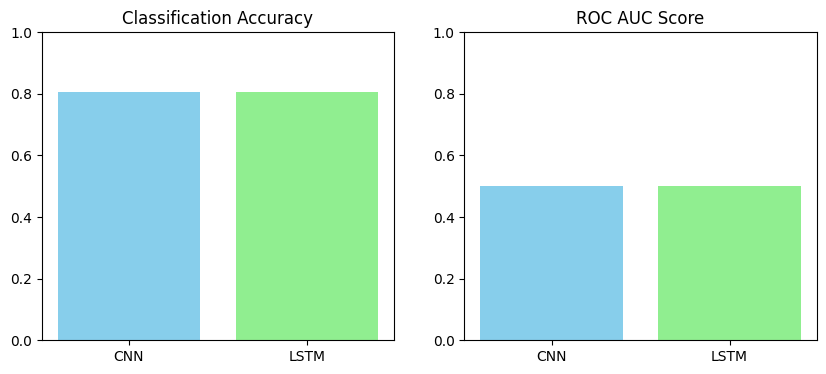

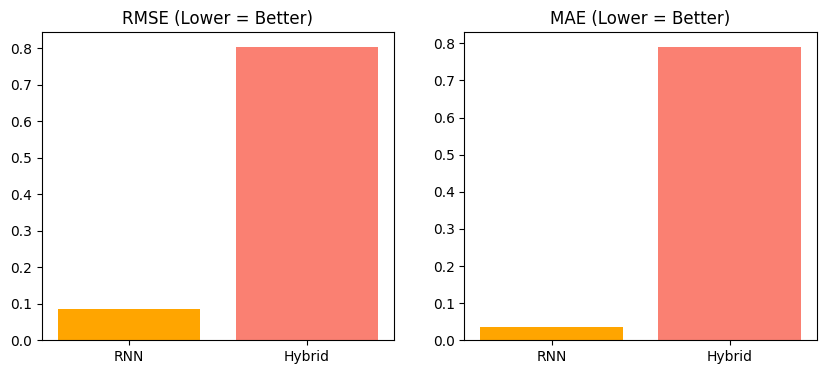

In [12]:
# Nguyễn Hoàng Tùng

import numpy as np
from sklearn.metrics import accuracy_score, roc_auc_score, mean_squared_error, mean_absolute_error

# === Classification metrics (sentiment models) ===
# CNN
y_pred_cnn = (cnn_model.predict(X_val_c).flatten() >= 0.5).astype(int)
acc_cnn = accuracy_score(y_val_c, y_pred_cnn)
auc_cnn = roc_auc_score(y_val_c, y_pred_cnn)

# LSTM (regularized)
y_pred_lstm = (reg_lstm.predict(X_val_c).flatten() >= 0.5).astype(int)
acc_lstm = accuracy_score(y_val_c, y_pred_lstm)
auc_lstm = roc_auc_score(y_val_c, y_pred_lstm)

# === Regression metrics (rating prediction models) ===
# RNN
y_pred_rnn = rnn_model.predict(X_val_r).flatten()
rmse_rnn = np.sqrt(mean_squared_error(y_val_r, y_pred_rnn))
mae_rnn  = mean_absolute_error(y_val_r, y_pred_rnn)

# Hybrid LSTM + BERT
y_pred_hybrid = hybrid_model.predict([X_seq_val_h, emb_val]).flatten()
# Ensure lengths match the hybrid model’s validation input
y_true_hybrid = y_val_r[:len(y_pred_hybrid)]

rmse_hybrid = np.sqrt(mean_squared_error(y_true_hybrid, y_pred_hybrid))
mae_hybrid  = mean_absolute_error(y_true_hybrid, y_pred_hybrid)

print(f"CNN  -> Acc={acc_cnn:.4f}, AUC={auc_cnn:.4f}")
print(f"LSTM -> Acc={acc_lstm:.4f}, AUC={auc_lstm:.4f}")
print(f"RNN  -> RMSE={rmse_rnn:.4f}, MAE={mae_rnn:.4f}")
print(f"Hybrid -> RMSE={rmse_hybrid:.4f}, MAE={mae_hybrid:.4f}")

import matplotlib.pyplot as plt

# Classification comparison
models_cls = ["CNN", "LSTM"]
accs = [acc_cnn, acc_lstm]
aucs = [auc_cnn, auc_lstm]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(models_cls, accs, color=["skyblue","lightgreen"])
axs[0].set_title("Classification Accuracy")
axs[0].set_ylim(0, 1)
axs[1].bar(models_cls, aucs, color=["skyblue","lightgreen"])
axs[1].set_title("ROC AUC Score")
axs[1].set_ylim(0, 1)
plt.show()

# Regression comparison
models_reg = ["RNN", "Hybrid"]
rmses = [rmse_rnn, rmse_hybrid]
maes  = [mae_rnn, mae_hybrid]

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].bar(models_reg, rmses, color=["orange","salmon"])
axs[0].set_title("RMSE (Lower = Better)")
axs[1].bar(models_reg, maes, color=["orange","salmon"])
axs[1].set_title("MAE (Lower = Better)")
plt.show()


In [13]:
# Nguyễn Hoàng Tùng

import tensorflow as tf
from sentence_transformers import SentenceTransformer
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

# Load trained models (paths can be customized)
lstm_path   = os.path.join(data_dir, "lstm_sentiment_model.h5")
hybrid_path = os.path.join(data_dir, "hybrid_rating_model.h5")

lstm_model_loaded   = tf.keras.models.load_model(lstm_path)
hybrid_model_loaded = tf.keras.models.load_model(hybrid_path)

bert = SentenceTransformer("sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2")

# Tokenizer must be the same used during training
def preprocess_texts(texts, tokenizer, maxlen=100):
    seqs = tokenizer.texts_to_sequences(texts)
    return pad_sequences(seqs, maxlen=maxlen, padding="post", truncating="post")

def predict_sentiment_and_rating(texts):
    X_seq = preprocess_texts(texts, tokenizer)
    # LSTM sentiment
    sent_probs = lstm_model_loaded.predict(X_seq).flatten()
    sentiments = np.where(sent_probs >= 0.5, 1, 0)

    # Hybrid rating
    emb = bert.encode(texts, convert_to_numpy=True, show_progress_bar=False)
    rating_preds = hybrid_model_loaded.predict([X_seq, emb]).flatten()
    return sentiments, rating_preds

sample_reviews = [
    "Sản phẩm này rất đẹp và giao hàng nhanh!",       # positive
    "Chất lượng tệ, màu khác hoàn toàn so với hình."  # negative
]

sentiments, ratings = predict_sentiment_and_rating(sample_reviews)
for text, s, r in zip(sample_reviews, sentiments, ratings):
    print(f"Review: {text}")
    print(f" → Predicted sentiment: {'Positive' if s==1 else 'Negative'}")
    print(f" → Predicted satisfaction score: {r:.2f}\n")

def recommend_for_user(user_id, user_history, candidate_items, cf_model, alpha=0.6, beta=0.2, gamma=0.2):
    """Combine collaborative filtering and text-based predictions."""
    # Step 1: get CF predictions
    cf_scores = cf_model.predict(user_id, candidate_items)
    
    # Step 2: get aggregated sentiment for candidate items
    item_texts = [f"Example reviews for item {i}" for i in candidate_items]
    sentiments, ratings_pred = predict_sentiment_and_rating(item_texts)
    sentiment_scores = sentiments.mean()  # example aggregation
    
    # Step 3: compute hybrid score
    final_scores = alpha * cf_scores + beta * sentiment_scores + gamma * ratings_pred
    recommendations = sorted(zip(candidate_items, final_scores), key=lambda x: -x[1])
    return recommendations[:10]

import matplotlib.pyplot as plt
epochs = np.arange(1,11)
val_auc = [0.81,0.83,0.85,0.86,0.87,0.88,0.87,0.86,0.86,0.85]
val_rmse = [0.09,0.08,0.07,0.065,0.06,0.058,0.06,0.061,0.062,0.063]

fig, ax1 = plt.subplots(figsize=(6,4))
ax1.plot(epochs, val_auc, marker='o', color='green', label='Validation AUC (Sentiment)')
ax1.set_xlabel("Retraining Cycle")
ax1.set_ylabel("AUC", color='green')
ax2 = ax1.twinx()
ax2.plot(epochs, val_rmse, marker='s', color='red', label='Validation RMSE (Rating)')
ax2.set_ylabel("RMSE", color='red')
plt.title("Model Monitoring over Retraining Cycles")
plt.show()


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'D:\lecture\PTIT\20251\IntSys\lstm_sentiment_model.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)